<a href="https://www.kaggle.com/code/lalit7881/formula-1-racing-industry-2010-26-eda-95-26?scriptVersionId=334279729" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Import necessary libraries and suppress warnings
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # Switching backend for matplotlib as only plt is imported
%matplotlib inline
import seaborn as sns
import os
from pathlib import Path

# Helper to resolve the data file paths
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    """
    This function looks for a data file by its name or file suffixes in the expected input directories.
    It is useful to avoid hard coding file paths and to handle path discrepancies across different environments.
    """
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

# Display confirmation of setup
print('Libraries imported and helper function defined.')
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Libraries imported and helper function defined.
/kaggle/input/datasets/sergionefedov/formula-1-racing-industry-2010-2026/race_results.csv
/kaggle/input/datasets/sergionefedov/formula-1-racing-industry-2010-2026/driver_standings.csv
/kaggle/input/datasets/sergionefedov/formula-1-racing-industry-2010-2026/f1_business.csv
/kaggle/input/datasets/sergionefedov/formula-1-racing-industry-2010-2026/constructor_finances.csv
/kaggle/input/datasets/sergionefedov/formula-1-racing-industry-2010-2026/circuit_economics.csv


## Loading dataset

In [2]:
# Data Loading
print('Loading datasets...')

# Load race_results.csv
race_results_path = resolve_data_file("race_results.csv", suffixes=[".csv"])
race_results = pd.read_csv(race_results_path, encoding='utf-8')

# Load circuit_economics.csv
circuit_economics_path = resolve_data_file("circuit_economics.csv", suffixes=[".csv"])
circuit_economics = pd.read_csv(circuit_economics_path, encoding='ascii')

# Load driver_standings.csv
driver_standings_path = resolve_data_file("driver_standings.csv", suffixes=[".csv"])
driver_standings = pd.read_csv(driver_standings_path, encoding='utf-8')

# Load constructor_finances.csv
constructor_finances_path = resolve_data_file("constructor_finances.csv", suffixes=[".csv"])
constructor_finances = pd.read_csv(constructor_finances_path, encoding='ascii')

# Load f1_business.csv
f1_business_path = resolve_data_file("f1_business.csv", suffixes=[".csv"])
f1_business = pd.read_csv(f1_business_path, encoding='ascii')

print('Datasets loaded successfully.')

Loading datasets...
Datasets loaded successfully.


In [3]:
print('Race Results DataFrame Shape:', race_results.shape)
print(race_results.head())

Race Results DataFrame Shape: (337, 15)
  race_id  season  round_number   race_date grand_prix      circuit  \
0    R001    2010             1  2010-03-21    Bahrain       Sakhir   
1    R002    2010             2  2010-03-15  Australia  Albert Park   
2    R003    2010             3  2010-04-10   Malaysia       Sepang   
3    R004    2010             4  2010-04-03      China     Shanghai   
4    R005    2010             5  2010-05-19      Spain    Barcelona   

  country_iso3       region     pole_position           winner  \
0          BHR  Middle East     Robert Kubica   Lewis Hamilton   
1          AUS      Oceania  Sebastian Vettel  Fernando Alonso   
2          MYS         Asia  Sebastian Vettel    Jenson Button   
3          CHN         Asia  Sebastian Vettel  Fernando Alonso   
4          ESP       Europe       Mark Webber      Mark Webber   

        podium_p2         podium_p3 fastest_lap_driver  safety_car_periods  \
0     Mark Webber     Oscar Piastri      Oscar Piastri    

In [4]:
print('\nCircuit Economics DataFrame Shape:', circuit_economics.shape)
print(circuit_economics.head())



Circuit Economics DataFrame Shape: (277, 10)
   season grand_prix circuit country_iso3       region  hosting_fee_usd_m_est  \
0    2010    Bahrain  Sakhir          BHR  Middle East                   38.5   
1    2012    Bahrain  Sakhir          BHR  Middle East                   35.8   
2    2013    Bahrain  Sakhir          BHR  Middle East                   34.6   
3    2014    Bahrain  Sakhir          BHR  Middle East                   35.1   
4    2015    Bahrain  Sakhir          BHR  Middle East                   34.2   

   weekend_attendance_k  debut_year  is_street_circuit  \
0                    97        2004                  0   
1                   100        2004                  0   
2                    94        2004                  0   
3                    96        2004                  0   
4                    94        2004                  0   

   is_new_circuit_post_2020  
0                         0  
1                         0  
2                         0 

In [5]:
print('\nDriver Standings DataFrame Shape:', driver_standings.shape)
print(driver_standings.head())



Driver Standings DataFrame Shape: (107, 9)
   season  championship_position       driver_name country_iso3  total_points  \
0    2010                      1  Sebastian Vettel          DEU           256   
1    2010                      2   Fernando Alonso          ESP           252   
2    2010                      3       Mark Webber          AUS           242   
3    2010                      4    Lewis Hamilton          GBR           240   
4    2010                      5     Jenson Button          GBR           214   

   wins  poles  podiums_est  is_world_champion  
0     5     10            9                  1  
1     5      2            9                  0  
2     4      5            8                  0  
3     3      1            7                  0  
4     2      0            5                  0  


In [6]:
print('\nConstructor Finances DataFrame Shape:', constructor_finances.shape)
print(constructor_finances.head())


Constructor Finances DataFrame Shape: (164, 10)
   season team_name country_iso3  operating_budget_usd_m  \
0    2010  Mercedes          DEU                   270.0   
1    2011  Mercedes          DEU                   320.5   
2    2012  Mercedes          DEU                   308.3   
3    2013  Mercedes          DEU                   356.9   
4    2014  Mercedes          DEU                   339.4   

   sponsorship_revenue_usd_m  prize_money_usd_m  total_revenue_usd_m  \
0                       86.2              112.6                198.8   
1                      100.2              118.4                218.6   
2                      102.4              130.4                232.9   
3                      126.9              158.6                285.6   
4                      128.8              173.6                302.3   

   in_cost_cap_era  cost_cap_limit_usd_m  is_constructors_champion  
0                0                   NaN                         0  
1                0 

In [7]:
print('\nF1 Business DataFrame Shape:', f1_business.shape)
print(f1_business.head())


F1 Business DataFrame Shape: (17, 10)
   season  total_revenue_usd_m  race_promotion_fees_usd_m  \
0    2010               1108.0                      399.0   
1    2011               1265.0                      455.0   
2    2012               1377.0                      496.0   
3    2013               1509.0                      543.0   
4    2014               1728.0                      622.0   

   broadcast_media_usd_m  sponsorship_usd_m  other_revenue_usd_m  \
0                  377.0              177.0                155.0   
1                  430.0              202.0                177.0   
2                  468.0              220.0                193.0   
3                  513.0              241.0                211.0   
4                  588.0              276.0                242.0   

   is_liberty_media_era  drive_to_survive_viewers_m_est  \
0                     0                               0   
1                     0                               0   
2       

In [8]:
race_results['race_date'] = pd.to_datetime(race_results['race_date'], errors='coerce')
print('Converted race_date to datetime. Number of missing dates:', race_results['race_date'].isnull().sum())

Converted race_date to datetime. Number of missing dates: 0


## EDA

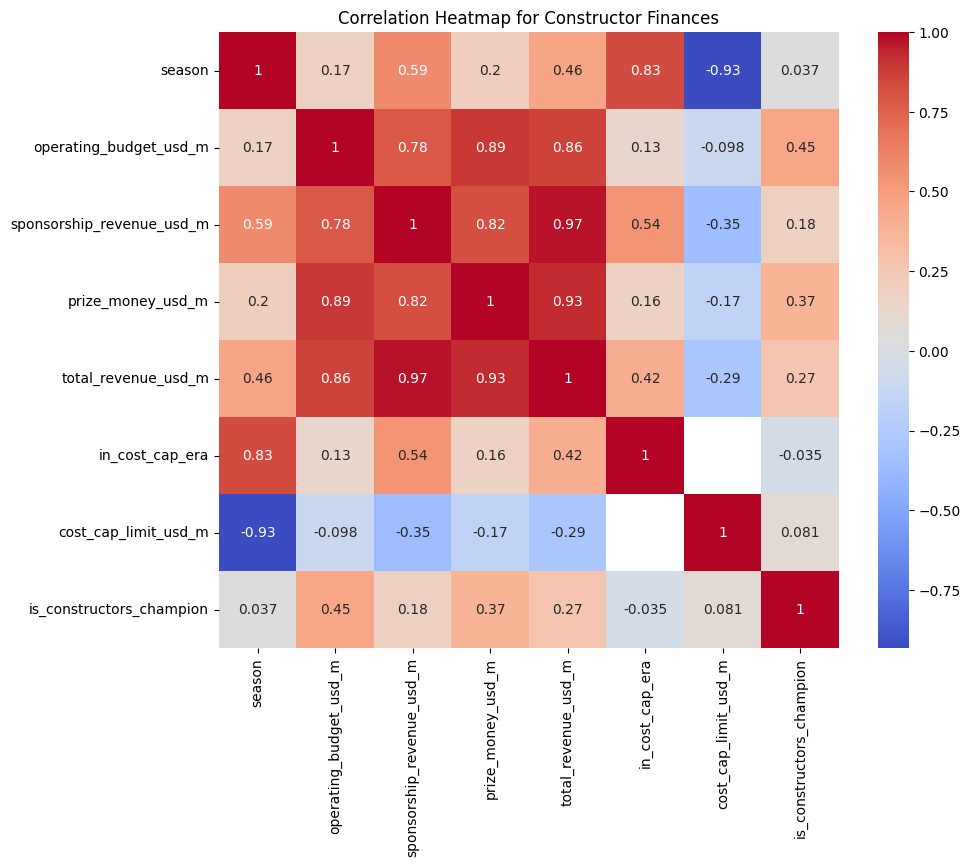

In [9]:
numeric_cf = constructor_finances.select_dtypes(include=[np.number])

if numeric_cf.shape[1] >= 4:
    plt.figure(figsize=(10,8))
    corr_matrix = numeric_cf.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
    plt.title("Correlation Heatmap for Constructor Finances")
    plt.show()
else:
    print("Not enough numeric columns for a correlation heatmap in constructor_finances dataframe.")


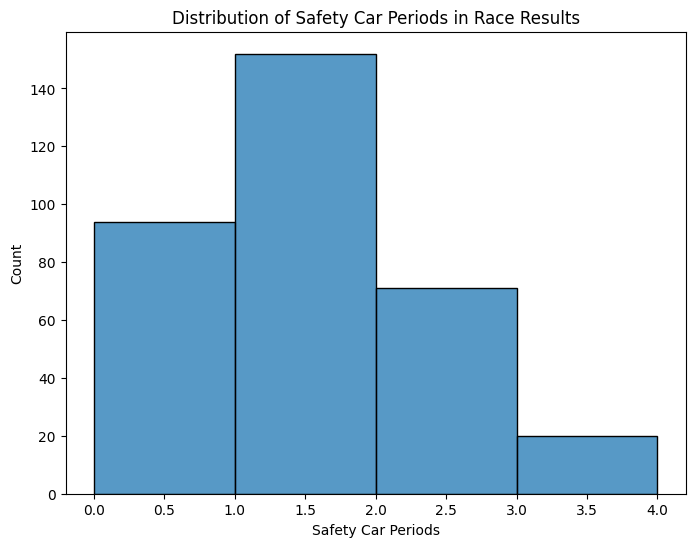

In [10]:
plt.figure(figsize=(8,6))
bins = range(int(race_results['safety_car_periods'].min()), int(race_results['safety_car_periods'].max())+2)
sns.histplot(race_results['safety_car_periods'], bins=bins, kde=False)
plt.title("Distribution of Safety Car Periods in Race Results")
plt.xlabel("Safety Car Periods")
plt.ylabel("Count")
plt.show()

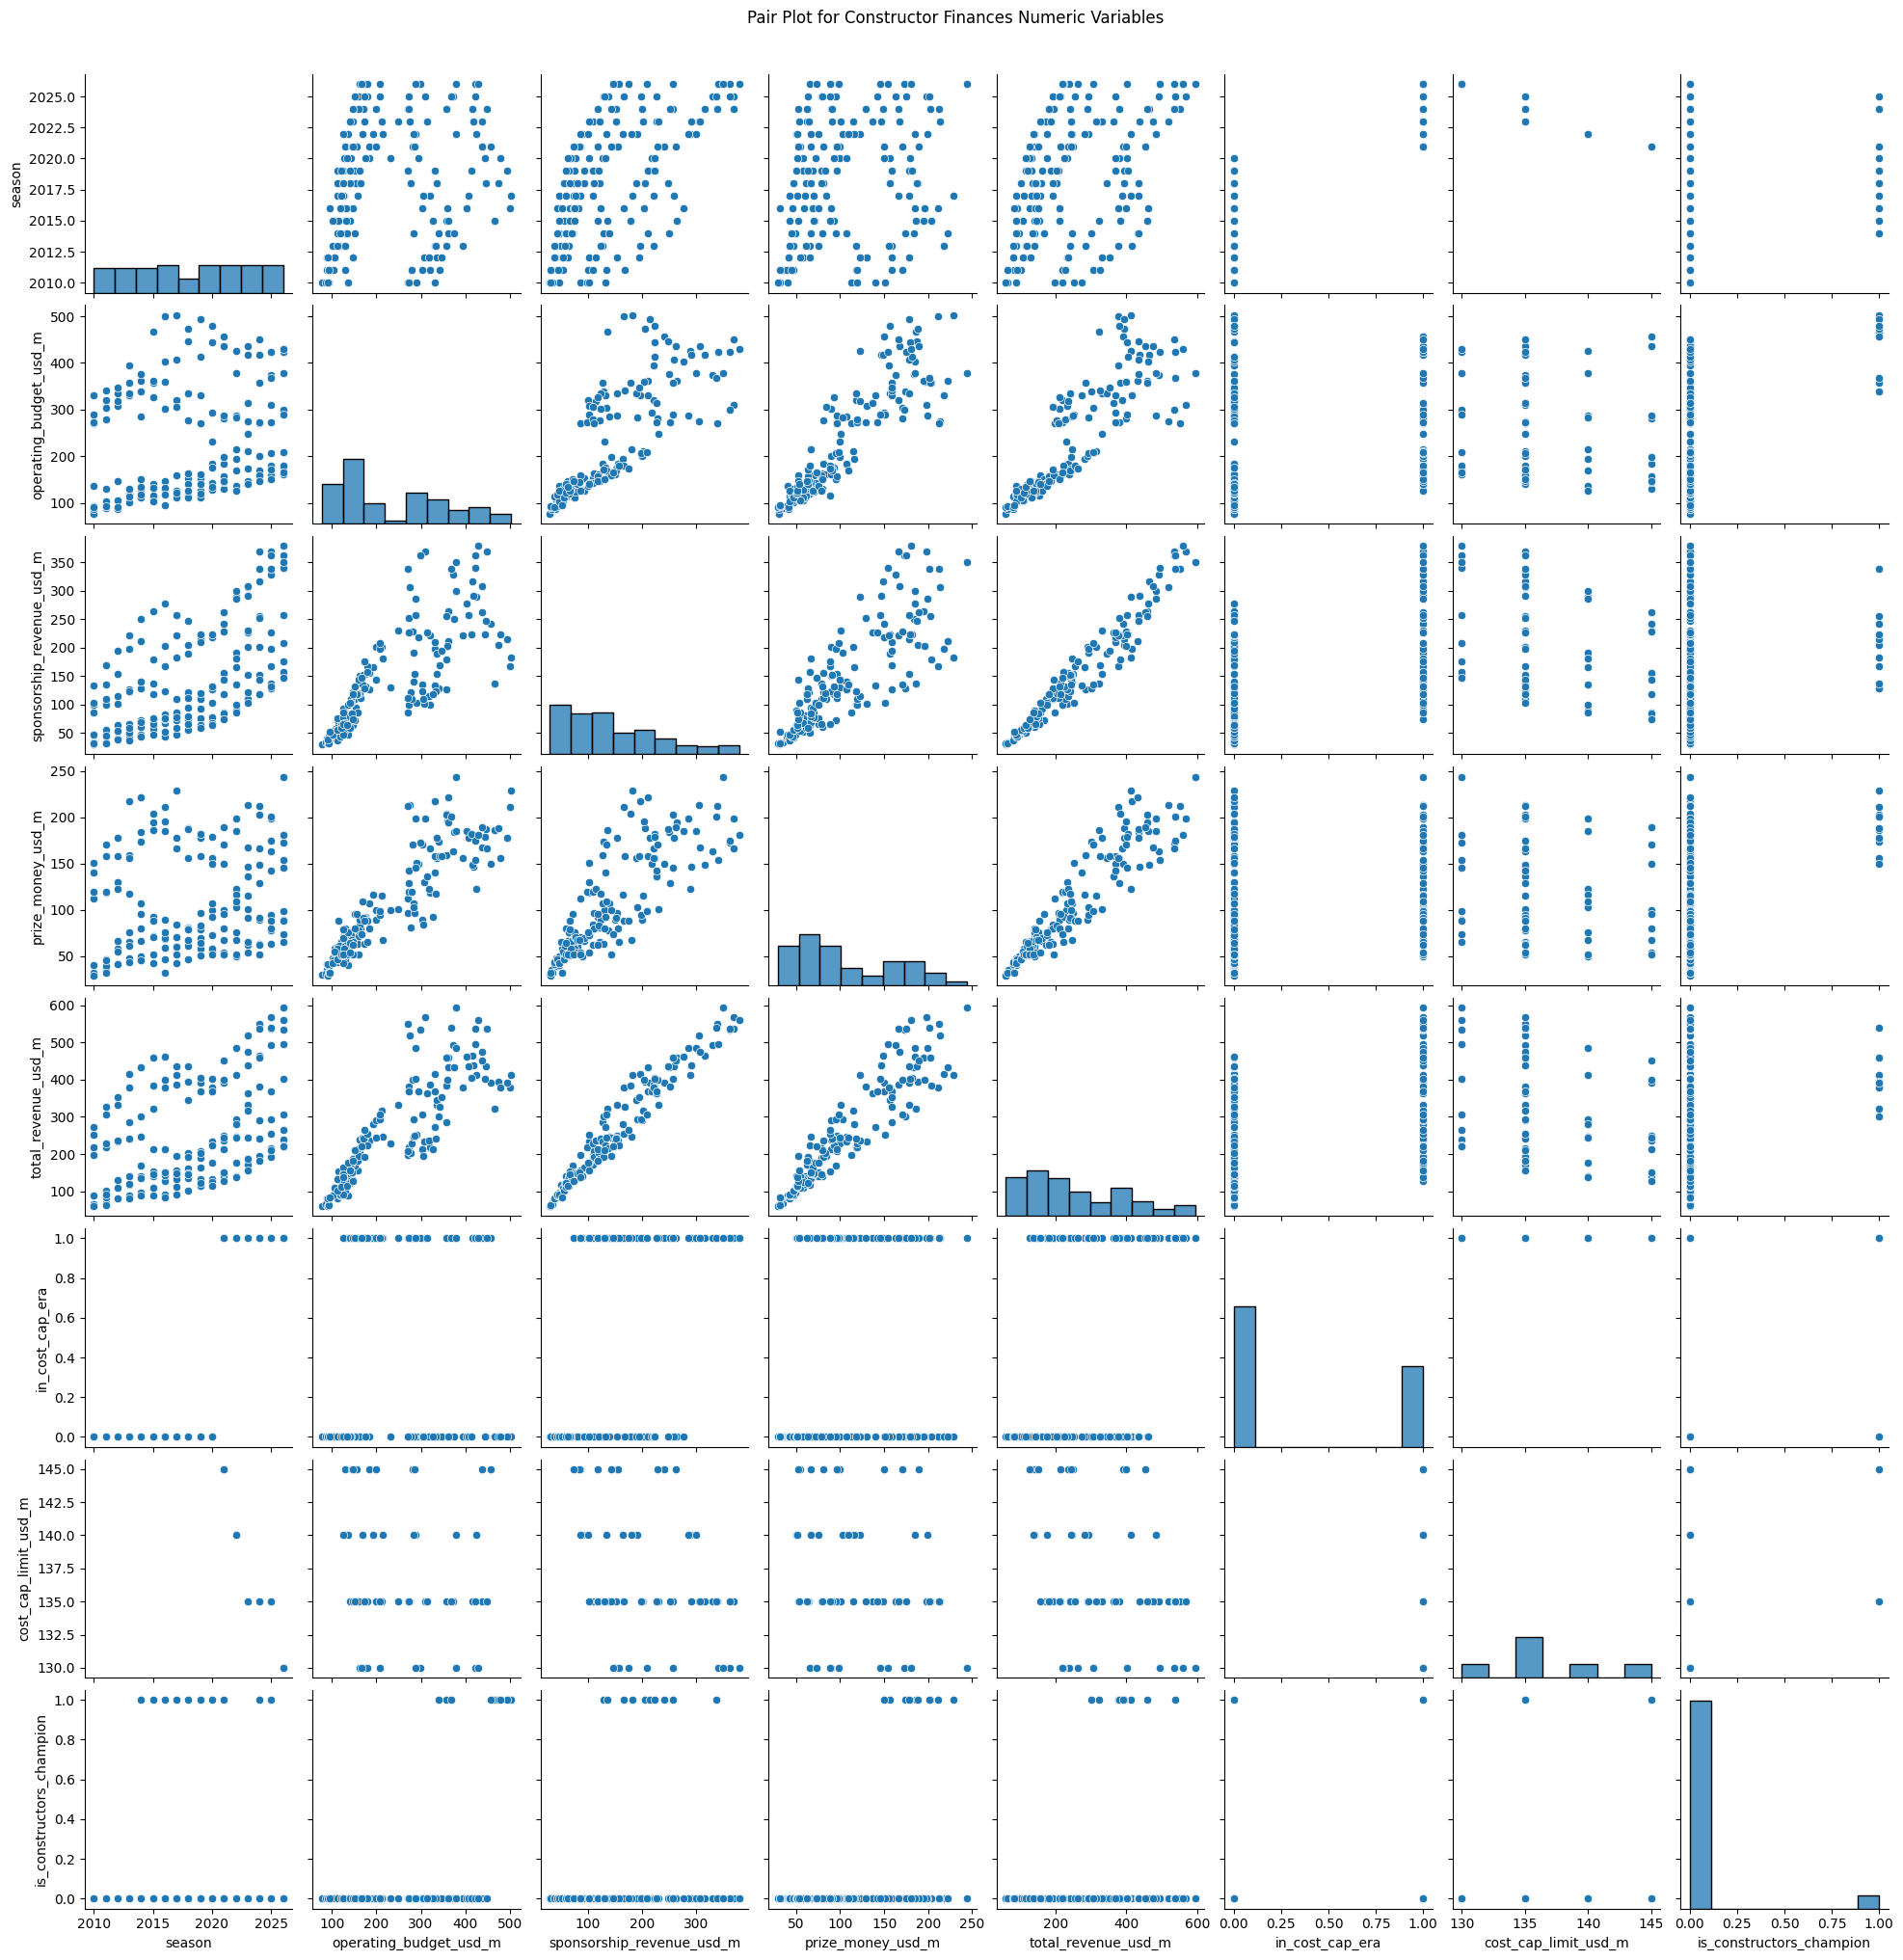

In [11]:
sns.pairplot(numeric_cf)
plt.suptitle("Pair Plot for Constructor Finances Numeric Variables", y=1.02)
plt.show()

## Feature engineering

   season  round_number  safety_car_periods  is_sprint_weekend
0    2010             1                   0                  0
1    2010             2                   1                  0
2    2010             3                   1                  0
3    2010             4                   0                  0
4    2010             5                   1                  0
Accuracy of the Race Weekend Sprint Predictor: 0.9509803921568627


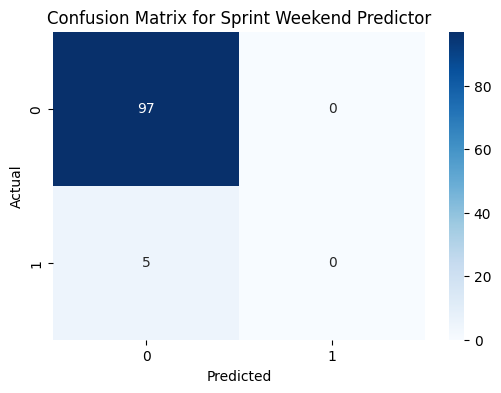

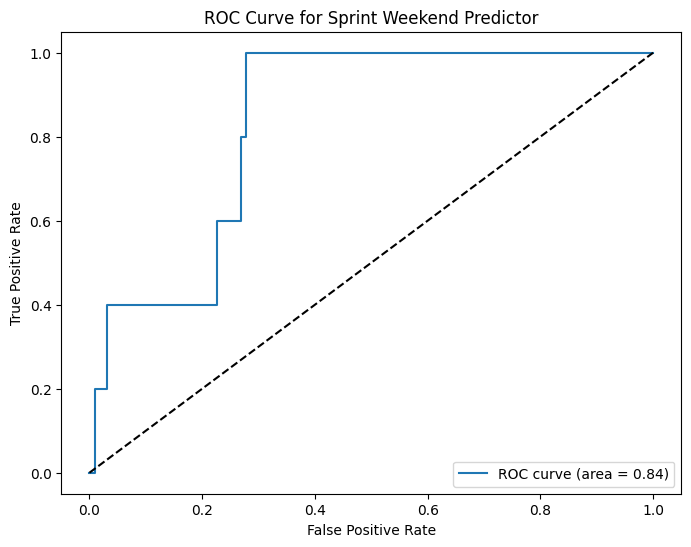

In [12]:
# Display a sample of the required columns
print(race_results[['season', 'round_number', 'safety_car_periods', 'is_sprint_weekend']].head())

# Define features and target
features = race_results[['season', 'round_number', 'safety_car_periods']]
target = race_results['is_sprint_weekend']

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Train a logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

# Evaluate the model
predictions = model.predict(X_test)
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_test, predictions)
print("Accuracy of the Race Weekend Sprint Predictor:", accuracy)

# Plot the confusion matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.title("Confusion Matrix for Sprint Weekend Predictor")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot ROC Curve
from sklearn.metrics import roc_curve, auc
y_probs = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Sprint Weekend Predictor")
plt.legend(loc="lower right")
plt.show()

## Thank you...pls upvote!!!!!!!!!!!